* You can add as many cells as you need to answer the questions.
* You can also answer any word or math based questions in a markup cell.
* Plots should have labels on the axes, legends if appropriate etc.

# Assignment 1 :  MC Simulations of Estimators of Location and Spread

In [1]:
import numpy as np
import scipy.stats

import matplotlib
import matplotlib.pyplot as plt

# Adjust default font size so that labels are readable in plots
font = {'size': 12}
matplotlib.rc('font', **font)
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['figure.figsize'] = [6, 4]
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

For full marks, write the code below as a function or suite of functions that accepts another function (e.g. one that calculates $s^2$ or $s$) as an argument.

## Q1

For the first exercise you will use ``numpy`` and/or ``scipy`` and/or your own functions to test the formula for the estimated sample variance $s^2$.  

1. Do a _Monte Carlo_ (MC) simulation by drawing $M$ samples of $N$ data points, where $M$ is some very large number (like 10000). Each sample of $N$ data points is drawn from a Gaussian distribution with mean $\mu = 0$ and $\sigma^2 = 1$.

2. For each sample, <mark>calculate the _sample_ variance $s^2$</mark> using the standard formula. 
<mark>You can use builtin functions to do this on numpy arrays, or write your own. If the former, read the function docs carefully.</mark>

3. <mark>Save the values of $s^2$ in an array of length $M$</mark>. We are using a MC method to estimate what is called the _sampling distribution_, or, more specifically, the _sampling distribution of the sample variance_.

4. Then <mark>calculate the mean and variance of $s^2$ over all the $M$ MC samples</mark>, i.e the mean and variance of the sampling distribution.

5. Plot the mean $s^2$ (over all $M$ MC samples), $\overline{s^2}$, along with errorbars that show the <mark>_standard error_ in $\overline{s^2}$ (not the standard deviation of $s^2$)</mark>, as a function of $N$ from $N = 2$ to $N = 30$. Plot a line showing the <mark>expected value of $s^2$ for the population</mark>.

6. What is the $\chi^2$ of the simulated data points plotted in 5) compared to the model line? Is it an acceptable fit?

7. Based on this Monte Carlo experiment, is the sample variance estimator ($s^2$) unbiased?


### Step 1

In [2]:
def compute_variance_of_sample(data):
    variance = np.var(data, ddof=1)         # ddof = 1 because we are estimating the mean from the data (N-1 factor)
    
    return variance

def estimate_metric_by_drawing_M_samples_from_N_data_points_drawn_from_normal_distribution(function_that_computes_metric, M, N, rng):
    estimates_for_each_sample = np.empty(shape=M)

    for i in range(0,M):
        sample = rng.normal(loc=0,scale=1,size=N)            # N(mu=0,std=1)
        estimates_for_each_sample[i] = function_that_computes_metric(sample)

    return estimates_for_each_sample

def compute_standard_error_of_sample(sample_variance, N):
    standard_error = np.sqrt(sample_variance / N)

    return standard_error


In [3]:
M = 10000       # Number of samples to be drawn, we draw M times a sample containing N data points taken from N~N(0,1)
N_array = np.linspace(2, 30, num=29, dtype=int)

rng = np.random.default_rng()

### Step 2 and 3 

In [4]:
# !running this cell randomizes values again! 
estimates_of_variance = []          # holds the variances estimated by each individual 10000 runs with N data points, for each N                            # shape (29, 10000)

for N in N_array:
    variance_estimates = estimate_metric_by_drawing_M_samples_from_N_data_points_drawn_from_normal_distribution(compute_variance_of_sample, M, N, rng)      # shape (10000,), contains 10000 variance values for a given N 
    estimates_of_variance.append(variance_estimates)

print(estimates_of_variance)        # array of 10000 s2 values for each N

[array([0.79403856, 8.31075832, 0.5726234 , ..., 0.96713579, 0.20798285,
       1.22163596], shape=(10000,)), array([1.10391264, 0.8732629 , 0.67967321, ..., 0.58766821, 1.99412881,
       0.07555582], shape=(10000,)), array([2.23115609, 1.03768166, 0.29404201, ..., 0.2016261 , 0.78729466,
       0.46093777], shape=(10000,)), array([1.03004059, 0.86438606, 0.1825108 , ..., 0.10710064, 1.90556679,
       0.75098439], shape=(10000,)), array([1.68180278, 1.49758427, 0.87507467, ..., 0.51533956, 1.68965238,
       0.22439699], shape=(10000,)), array([0.93171656, 0.3310574 , 0.8721736 , ..., 1.14211118, 1.43437615,
       0.7048326 ], shape=(10000,)), array([1.03063159, 1.46180305, 0.88892914, ..., 1.84636429, 0.60969488,
       0.39646639], shape=(10000,)), array([0.42375653, 0.68987857, 0.45021623, ..., 0.71709012, 0.86750641,
       1.3731393 ], shape=(10000,)), array([1.00101349, 1.22178236, 2.27102404, ..., 1.11725798, 0.76784105,
       0.28320653], shape=(10000,)), array([0.90629306,

### Step 4

In [5]:
means_of_estimates_of_variance = []      # holds the mean of all 10000 variances computed for a given N                  # shape (29, 1)
for estimates in estimates_of_variance: 
    mean = np.mean(estimates)           # computes the mean of all 10000 variances          # shape (1,)
    means_of_estimates_of_variance.append(mean)   

variances_of_estimates_of_variance = []  # holds the variance of all the 10000 variances computed for a given N          # shape (29, 1)
for estimates in estimates_of_variance:
    var = np.var(estimates, ddof=1)                 # Bessel Correction Factor
    variances_of_estimates_of_variance.append(var)

print(means_of_estimates_of_variance)            # array of the avg of all 10000 s2 values for a given N     
print()
print(variances_of_estimates_of_variance)        # array of the s2 of all 10000 s2 values for a given N 

[np.float64(0.9959795301492299), np.float64(0.9974414844510602), np.float64(0.9988387413682424), np.float64(0.9993563901645613), np.float64(1.008295059739742), np.float64(0.9956057672686593), np.float64(0.9974308633648856), np.float64(0.9971542219062605), np.float64(1.0045164078574498), np.float64(1.0036407006746275), np.float64(0.99284707032313), np.float64(1.007397721928622), np.float64(1.0043907911881416), np.float64(1.0005612167237736), np.float64(1.0056034265102924), np.float64(1.0011756692447373), np.float64(0.9965688376921181), np.float64(0.9993590057923281), np.float64(1.0005897780216262), np.float64(0.9995405892890267), np.float64(0.9955784154005854), np.float64(0.9983260699753328), np.float64(1.0003693998543666), np.float64(1.003240212428829), np.float64(0.9950591464321292), np.float64(0.9961681222005813), np.float64(1.000610890348777), np.float64(0.9989181260351204), np.float64(1.001865439209386)]

[np.float64(1.974845942778931), np.float64(0.9592735454834922), np.float64(0.

### Step 5

standard error in the mean is:

$$
\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{N}} = \sqrt{ \frac{\sigma^2}{N} }
$$

but the population variance $\sigma^2$ is unknown, so we estimate the standard error by substituting the sample variance $s^2$

\begin{equation*}
    \sigma_{\bar{x}} = \sqrt{ \frac{s^2}{N} }
\end{equation*}

so that the standard error of the mean variance with M sample size is 

\begin{equation*}
    \sigma_{\bar{s^2}} = \sqrt{ \frac{\rm var(s^2)}{M} }
\end{equation*}

In [6]:
standard_errors_of_means_of_estimates_of_variance = []              # holds the stderr for each mean        # shape (29, 1)

for var in variances_of_estimates_of_variance:
    stderr = compute_standard_error_of_sample(var, N=M)             # computes the std err in the mean of the variances -> we computed the avg of all 10000 s2 values so N=10000
    standard_errors_of_means_of_estimates_of_variance.append(stderr)

print(standard_errors_of_means_of_estimates_of_variance)            # array of stderr for each mean of variance     # shape (29 , 1)

[np.float64(0.014052921200871125), np.float64(0.009794251096860301), np.float64(0.008177029484340658), np.float64(0.007075950266028947), np.float64(0.006298196744166335), np.float64(0.005712488016348087), np.float64(0.005241533882610708), np.float64(0.004939938352940564), np.float64(0.0047428881400216815), np.float64(0.004496405108320223), np.float64(0.004199115384337649), np.float64(0.00412958492625369), np.float64(0.004013832770208771), np.float64(0.0037560922995719184), np.float64(0.003648772840015982), np.float64(0.003582260029652101), np.float64(0.0034395019939533053), np.float64(0.003336909007620266), np.float64(0.003244331195131623), np.float64(0.003132855352335864), np.float64(0.003089545778557212), np.float64(0.003014909637139304), np.float64(0.0029681119249270133), np.float64(0.0028899193909459045), np.float64(0.0027735318185087153), np.float64(0.0027732985967835262), np.float64(0.0026979427553984695), np.float64(0.00263964385902057), np.float64(0.0025791904664397435)]


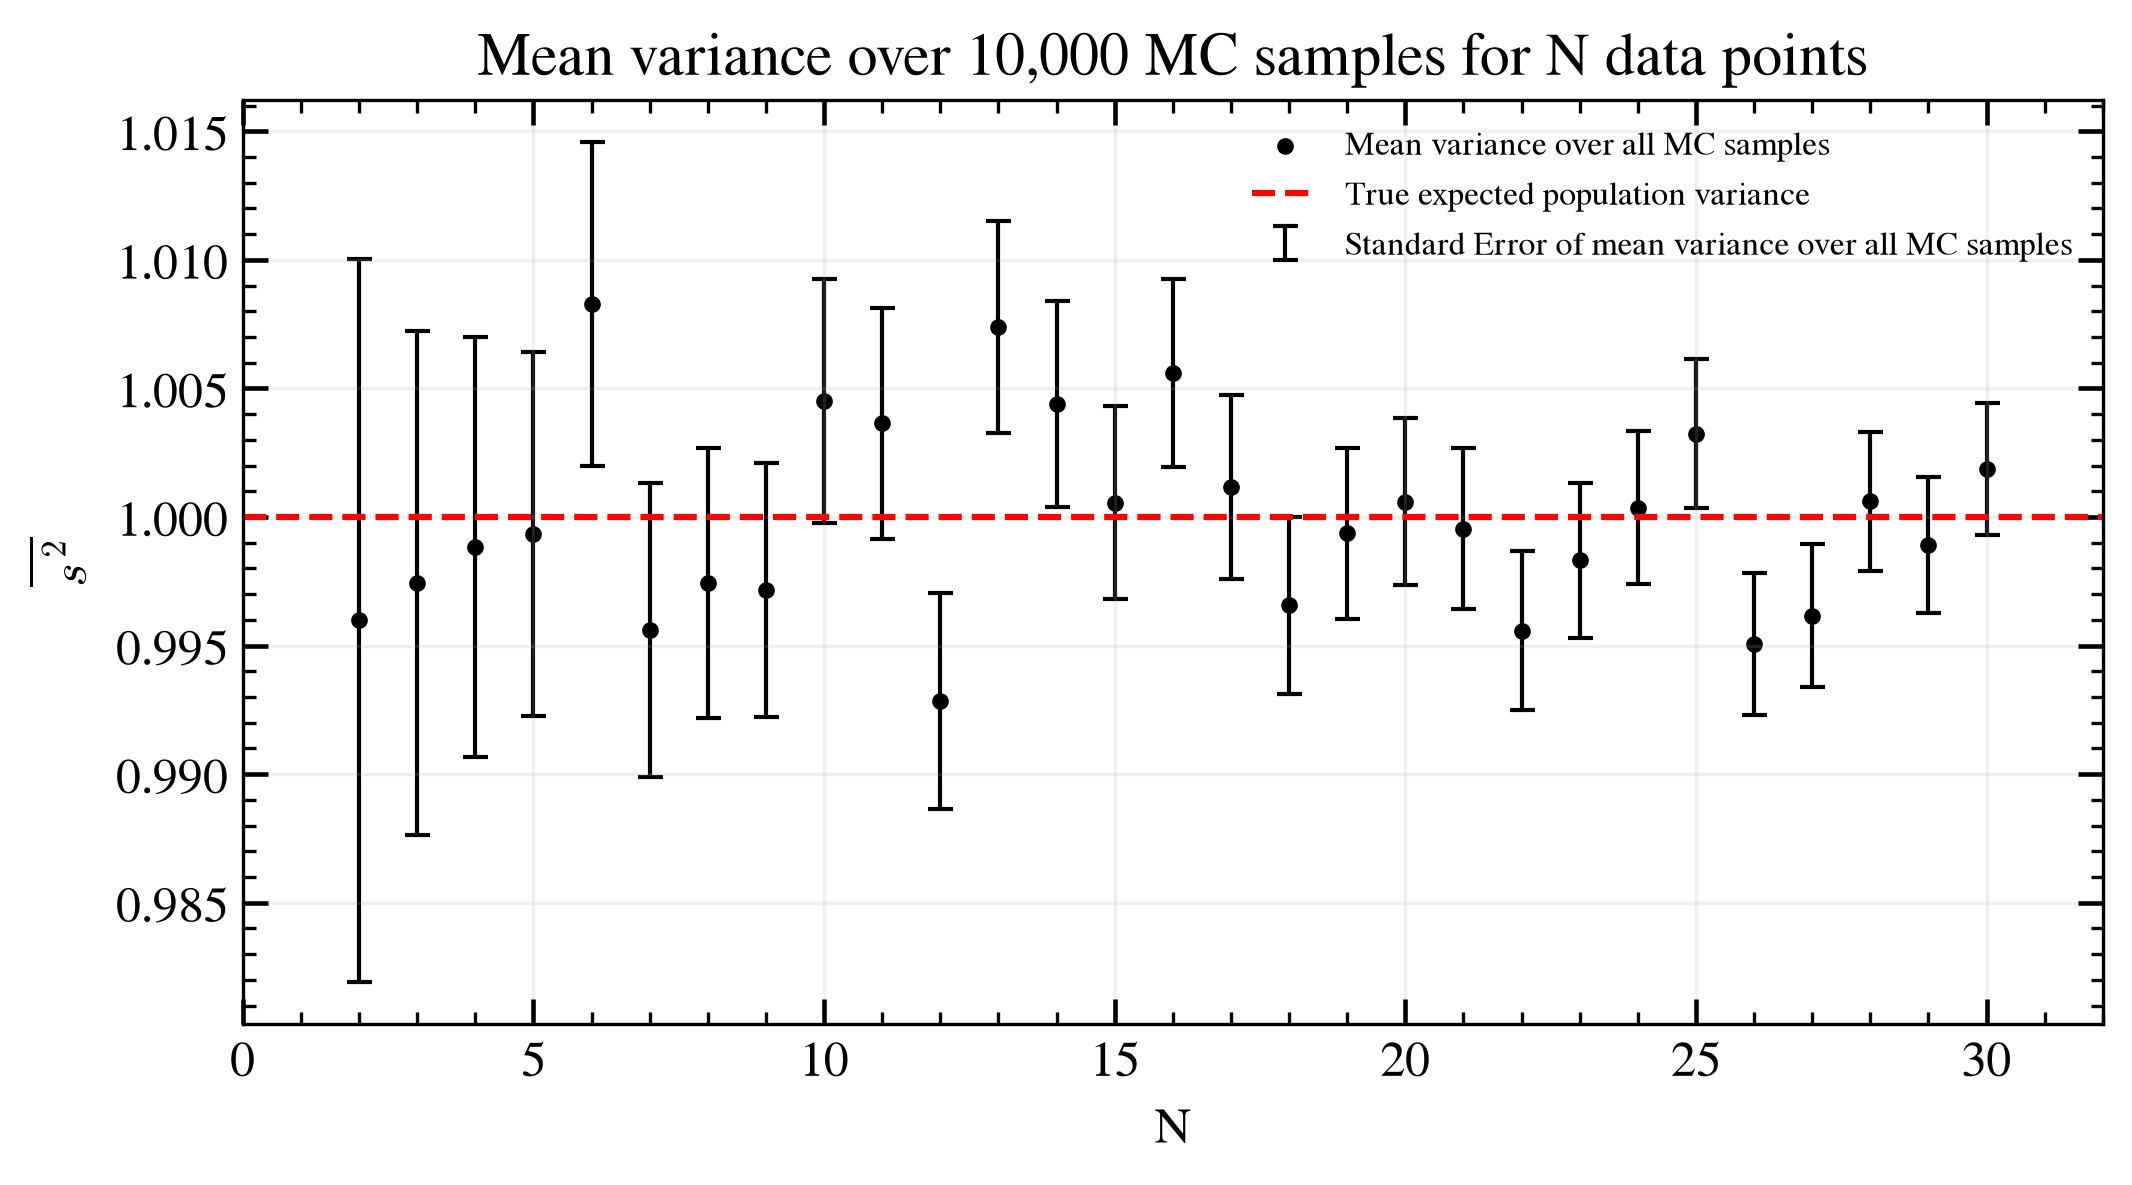

In [7]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)

ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.set_xlabel('N')
ax.set_ylabel(r'$\overline{s^2}$')
ax.set_title("Mean variance over 10,000 MC samples for N data points")
ax.set_xlim(0,32)
# ax.set_ylim(0.95,1.05)

ax.scatter(N_array, means_of_estimates_of_variance, marker='.', label="Mean variance over all MC samples", color='black')

ax.errorbar(N_array, means_of_estimates_of_variance, 
    yerr=standard_errors_of_means_of_estimates_of_variance,
    fmt="none",
    capsize=3,
    lw = 1.0, 
    label="Standard Error of mean variance over all MC samples",
    zorder= -3, 
    color = 'black'
)

ax.axhline(y=1, color= 'red', ls='dashed', label = 'True expected population variance')    # true E[s2] for normal ~N(0,1) is 1

ax.legend(frameon=False, fontsize=8, loc='best')

## Q2

In a variant of the above exercises, suppose for each sample of size $N$ drawn from a normal distribution, you calculate both the _sample_ mean $\bar{x}$ and the _sample_ variance $s^2$. Then define the statistic:
$$
Z = \frac{\bar{x}}{s/\sqrt{N}}
$$

a) For $N=5$, $M = 100,000$, plot a histogram of $Z$. Overplot a normal distribution.

b) Repeat for $N=100$.


c)  Is it the overplotted normal distribution [in parts a) and b)] a good fit? If not, why and in what way does it differ?

## Q3

Now repeat Q1, but in steps 2-6 replace the sample variance $s^2$ with its square root, the sample standard deviation $s$.

Are the results the same as for $s^2$? Explain.

## Q4

Repeat Q1 but calculate the sample _median_ instead of the sample variance.

Then calculate the mean and variance of the median over all the $M$ MC samples, i.e the mean and variance of the sampling distribution.

Plot the __ratio__ of the MC-estimated variance of the _median_ to the theoretical expectation for variance of the _mean_, as a function of $N$ from 5 to 500 (in steps of 20 or 25, say).

b) What is the asymptotic of this ratio for large $N$? Discuss the pros and cons of medians vs. means for the general case (i.e. the underlying distribution could be Gaussian or not).